In [46]:
from pysammos.data_write.h5.writer import H5XarrayManager
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [47]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams.update({'font.size': 16})
# axis labels and legend in 16 
matplotlib.rcParams.update({'axes.labelsize': 18})
matplotlib.rcParams.update({'legend.fontsize': 18})

## read data

In [48]:
# read PYSAMMOS data

# 1) 3D finite diff sweep data
# manager_lucy = H5XarrayManager("./PysammosCG_3D_finite_diff_gradient/w_sweep_Lucy.h5")
# pysammos_lucy = manager_lucy.h5_to_xarray(dim_name='w')
# manager_gaussian = H5XarrayManager("./PysammosCG_3D_finite_diff_gradient/w_sweep_Gaussian.h5")
# pysammos_gaussian = manager_gaussian.h5_to_xarray(dim_name='w')
# manager_heaviside = H5XarrayManager("./PysammosCG_3D_finite_diff_gradient/w_sweep_HeavySide.h5")
# pysammos_heaviside = manager_heaviside.h5_to_xarray(dim_name='w')
manager_lucy = H5XarrayManager("./PysammosCG_3D_finite_diff_gradient_newsign/w_sweep_Lucy.h5")
pysammos_lucy = manager_lucy.h5_to_xarray(dim_name='w')
manager_gaussian = H5XarrayManager("./PysammosCG_3D_finite_diff_gradient_newsign/w_sweep_Gaussian.h5")
pysammos_gaussian = manager_gaussian.h5_to_xarray(dim_name='w')
manager_heaviside = H5XarrayManager("./PysammosCG_3D_finite_diff_gradient_newsign/w_sweep_HeavySide.h5")
pysammos_heaviside = manager_heaviside.h5_to_xarray(dim_name='w')
# 2) No interpolation sweep data
manager_lucy_no_interp = H5XarrayManager("./PysammosCG_no_interpolation/w_sweep_Lucy.h5")
pysammos_lucy_no_interp = manager_lucy_no_interp.h5_to_xarray(dim_name='w') 
manager_gaussian_no_interp = H5XarrayManager("./PysammosCG_no_interpolation/w_sweep_Gaussian.h5")
pysammos_gaussian_no_interp = manager_gaussian_no_interp.h5_to_xarray(dim_name='w')
manager_heaviside_no_interp = H5XarrayManager("./PysammosCG_no_interpolation/w_sweep_HeavySide.h5")
pysammos_heaviside_no_interp = manager_heaviside_no_interp.h5_to_xarray(dim_name='w')
# 3) 3D least squares interpolation sweep data
manager_lucy_least_squares = H5XarrayManager("./PysammosCG_3D_least_squares_interp/w_sweep_Lucy.h5")
pysammos_lucy_least_squares = manager_lucy_least_squares.h5_to_xarray(dim_name='w')
manager_gaussian_least_squares = H5XarrayManager("./PysammosCG_3D_least_squares_interp/w_sweep_Gaussian.h5")
pysammos_gaussian_least_squares = manager_gaussian_least_squares.h5_to_xarray(dim_name='w')
manager_heaviside_least_squares = H5XarrayManager("./PysammosCG_3D_least_squares_interp/w_sweep_HeavySide.h5")
pysammos_heaviside_least_squares = manager_heaviside_least_squares.h5_to_xarray(dim_name='w')       

# 3) 3D least squares interpolation sweep data
manager_lucy_least_squares_newsign = H5XarrayManager("./PysammosCG_3D_least_squares_interp_newsign/w_sweep_Lucy.h5")
pysammos_lucy_least_squares_newsign = manager_lucy_least_squares_newsign.h5_to_xarray(dim_name='w')
manager_gaussian_least_squares_newsign = H5XarrayManager("./PysammosCG_3D_least_squares_interp_newsign/w_sweep_Gaussian.h5")
pysammos_gaussian_least_squares_newsign = manager_gaussian_least_squares_newsign.h5_to_xarray(dim_name='w')
manager_heaviside_least_squares_newsign = H5XarrayManager("./PysammosCG_3D_least_squares_interp_newsign/w_sweep_HeavySide.h5")
pysammos_heaviside_least_squares_newsign = manager_heaviside_least_squares_newsign.h5_to_xarray(dim_name='w')   

# read JP's data
jp_data = pd.read_csv("/exports/csce/datastore/geos/users/s1857688/Coarse_Graining/benchmarking_with_other_CG_codes/JP_monodisperse_CG.csv")

Processing key: contact_tensor
Processing key: density_mixture
Processing key: kinetic_tensor
Processing key: positions
Processing key: total_stress_tensor_xy_dev
Processing key: total_stress_tensor_xy_dev_mag
Processing key: total_stress_tensor_xyz
Processing key: total_stress_tensor_xyz_dev
Processing key: total_stress_tensor_xyz_dev_mag
Processing key: total_stress_tensor_xyz_mag
Processing key: velocity
Processing key: volume_fraction
Processing key: w
Processing key: contact_tensor
Processing key: density_mixture
Processing key: kinetic_tensor
Processing key: positions
Processing key: total_stress_tensor_xy_dev
Processing key: total_stress_tensor_xy_dev_mag
Processing key: total_stress_tensor_xyz
Processing key: total_stress_tensor_xyz_dev
Processing key: total_stress_tensor_xyz_dev_mag
Processing key: total_stress_tensor_xyz_mag
Processing key: velocity
Processing key: volume_fraction
Processing key: w
Processing key: contact_tensor
Processing key: density_mixture
Processing key:

In [41]:
jp_data.columns

Index(['Time', 'Width', 'Cut-off', 'Weight Function', 'Contact Stress XX',
       'Contact Stress XY', 'Contact Stress XZ', 'Contact Stress YX',
       'Contact Stress YY', 'Contact Stress YZ', 'Contact Stress ZX',
       'Contact Stress ZY', 'Contact Stress ZZ', 'Kinetic Stress XX',
       'Kinetic Stress XY', 'Kinetic Stress XZ', 'Kinetic Stress YY',
       'Kinetic Stress YZ', 'Kinetic Stress ZZ', 'Volume Fraction', 'Density',
       'Momentum X', 'Momentum Y', 'Momentum Z', 'Velocity X', 'Velocity Y',
       'Velocity Z', 'Particle Number', 'W/Dp'],
      dtype='object')

## functions

In [49]:
# functions

d = 0.02
point_ind = 13

def plot_JP_data(ax, marker, variable_name): 
    for i, (label, group) in enumerate(jp_data.groupby('Weight Function')):
        ax.scatter(
            group['W/Dp'], group[variable_name],
            marker=marker[i], label=label, s=100,
            color='white', edgecolors='k', 
            zorder=2)  


def select_component(arr, time_index=0, component=None):
    """
    arr: ndarray with shape (N, T, ...)

    component:
        None            → scalar
        int             → vector component
        tuple[int, ...] → tensor component
    """
    if component is None:
        return arr[:, time_index]

    if isinstance(component, int):
        component = (component,)

    return arr[(slice(None), time_index, *component)]



def plot_pysammos_data(ax, variable_name, component=None):
    datasets = [
        (pysammos_gaussian, 'Pysammos (finite diff) - Gaussian', "#B3FFB9"),
        (pysammos_heaviside, 'Pysammos (finite diff) - Heaviside', "#B3E9FF"),
        (pysammos_lucy, 'Pysammos (finite diff) - Lucy', "#BD5340"),
    ]

    for data, label, color in datasets:
        y = select_component(
            data[variable_name],
            time_index=point_ind,
            component=component
        )

        ax.scatter(
            data['w'] / d,
            y,
            marker='^',
            label=label,
            s=60,
            color=color,
            edgecolors='k',
            zorder=3
        )


def plot_pysammos_no_interp_data(ax, variable_name, component=None):
    datasets = [
        (pysammos_gaussian_no_interp, 'Pysammos (nearest) - Gaussian', "#B3FFB9"),
        (pysammos_heaviside_no_interp, 'Pysammos (nearest) - Heaviside', "#B3E9FF"),
        (pysammos_lucy_no_interp, 'Pysammos (nearest) - Lucy', "#BD5340"),
    ]

    for data, label, color in datasets:
        y = select_component(
            data[variable_name],
            time_index=point_ind,
            component=component
        )

        ax.scatter(
            data['w'] / d,
            y,
            marker='^',
            label=label,
            s=40,
            color=color, alpha=0.6,
            edgecolors='k',
            zorder=3
        )

def plot_pysammos_least_squares_data(ax, variable_name, component=None):
    datasets = [
        (pysammos_gaussian_least_squares, 'Pysammos (least squares) - Gaussian', "#B3FFB9"),
        (pysammos_heaviside_least_squares, 'Pysammos (least squares) - Heaviside', "#B3E9FF"),
        (pysammos_lucy_least_squares, 'Pysammos (least squares) - Lucy', "#BD5340"),
    ]

    for data, label, color in datasets:
        y = select_component(
            data[variable_name],
            time_index=point_ind,
            component=component
        )

        ax.scatter(
            data['w'] / d,
            y,
            marker='^',
            label=label,
            s=15,
            color=color, alpha=0.9,
            edgecolors='k',
            zorder=6
        )

def plot_pysammos_least_squares_newsign_data(ax, variable_name, component=None):
    datasets = [
        (pysammos_gaussian_least_squares_newsign, 'Pysammos (least squares) - Gaussian', "#B3FFB9"),
        (pysammos_heaviside_least_squares_newsign, 'Pysammos (least squares) - Heaviside', "#B3E9FF"),
        (pysammos_lucy_least_squares_newsign, 'Pysammos (least squares) - Lucy', "#BD5340"),
    ]

    for data, label, color in datasets:
        y = select_component(
            data[variable_name],
            time_index=point_ind,
            component=component
        )

        ax.scatter(
            data['w'] / d,
            y,
            marker='^',
            label=label,
            s=10,
            color='black', alpha=0.9,
            edgecolors='k',
            zorder=7
        )

## plot data

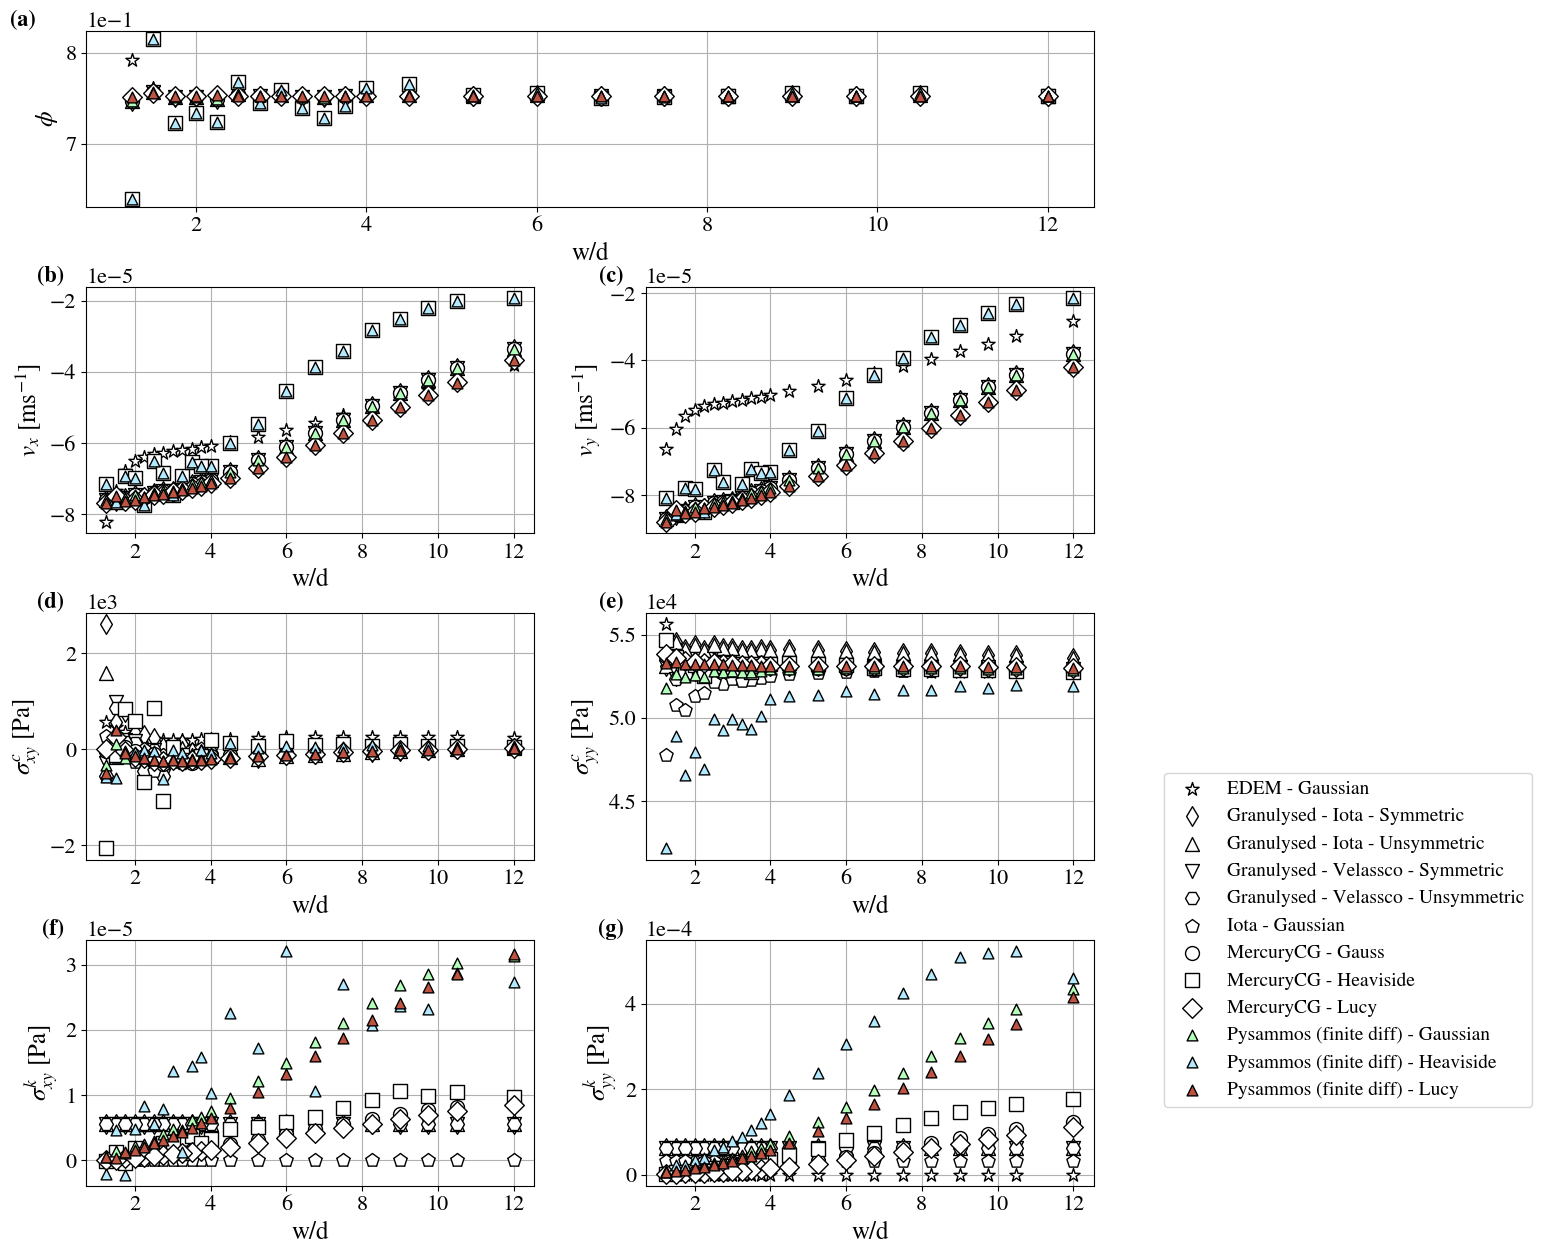

In [43]:
# FIGURE 
fig = plt.figure(figsize=(13, 15))
gs = fig.add_gridspec(4,2, height_ratios=[0.5, 0.7, 0.7, 0.7]) # 
ax0 = fig.add_subplot(gs[0, :])  # first column spans both rows
ax1 = fig.add_subplot(gs[1,0]) # 
ax2 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2,1])
ax3 = fig.add_subplot(gs[2,0])
ax5 = fig.add_subplot(gs[3,0])
ax6 = fig.add_subplot(gs[3,1])
axes = [ax0, ax1, ax2, ax3, ax4, ax5, ax6]

# GENERAL INFO 
marker = ['*', 'd', '^', 'v', 'H', 'p', 'o', 's', 'D']  # Different markers for each weight function

# 1. volume fraction 
plot_JP_data(ax0, marker, 'Volume Fraction'); ax0.set_ylabel(r'$\phi$')
plot_pysammos_data(ax0, 'volume_fraction')

# 2. velocity 
plot_JP_data(ax1, marker, 'Velocity X'); ax1.set_ylabel(r'$v_x$ [ms$^{-1}$]')
plot_pysammos_data(ax1, 'velocity', 0)

plot_JP_data(ax2, marker, 'Velocity Y'); ax2.set_ylabel(r'$v_y$ [ms$^{-1}$]')
plot_pysammos_data(ax2, 'velocity', 1)

# 3. contact tensor
plot_JP_data(ax3, marker, 'Contact Stress XY') ; ax3.set_ylabel(r'$\sigma^c_{xy}$ [Pa]')
plot_pysammos_data(ax3, 'contact_tensor', (0,1))

plot_JP_data(ax4, marker, 'Contact Stress YY') ; ax4.set_ylabel(r'$\sigma^c_{yy}$ [Pa]')
plot_pysammos_data(ax4, 'contact_tensor', (1,1))

# 4. yz kinetic stress
plot_JP_data(ax5, marker, 'Kinetic Stress XY') ; ax5.set_ylabel(r'$\sigma^k_{xy}$ [Pa]')
plot_pysammos_data(ax5, 'kinetic_tensor', (0,1))
#plot_pysammos_no_interp_data(ax5, 'kinetic_tensor', (0,1))

plot_JP_data(ax6, marker, 'Kinetic Stress YY') ; ax6.set_ylabel(r'$\sigma^k_{yy}$ [Pa]')
plot_pysammos_data(ax6, 'kinetic_tensor', (1,1))
#plot_pysammos_no_interp_data(ax6, 'kinetic_tensor', (1,1))

# add grid to all the subplots
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)']
for i in range(len(axes)): 
    ax = axes[i]
    ax.grid()
    ax.set_xlabel('w/d')
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(-1,1))
    ax.text(
        -0.05, 1.0, labels[i], transform=ax.transAxes, 
        fontsize=16, fontweight='bold', va='bottom', ha='right')

# legend
axes[6].legend(loc='center right', fontsize=14, bbox_to_anchor=(2, 1.))

plt.subplots_adjust(hspace=0.35, wspace=0.25)

plt.savefig('/exports/csce/datastore/geos/users/s1857688/Paper_Writing/coarse_graining/benchmark.png', dpi=600,
    bbox_inches='tight',
    pad_inches=0)

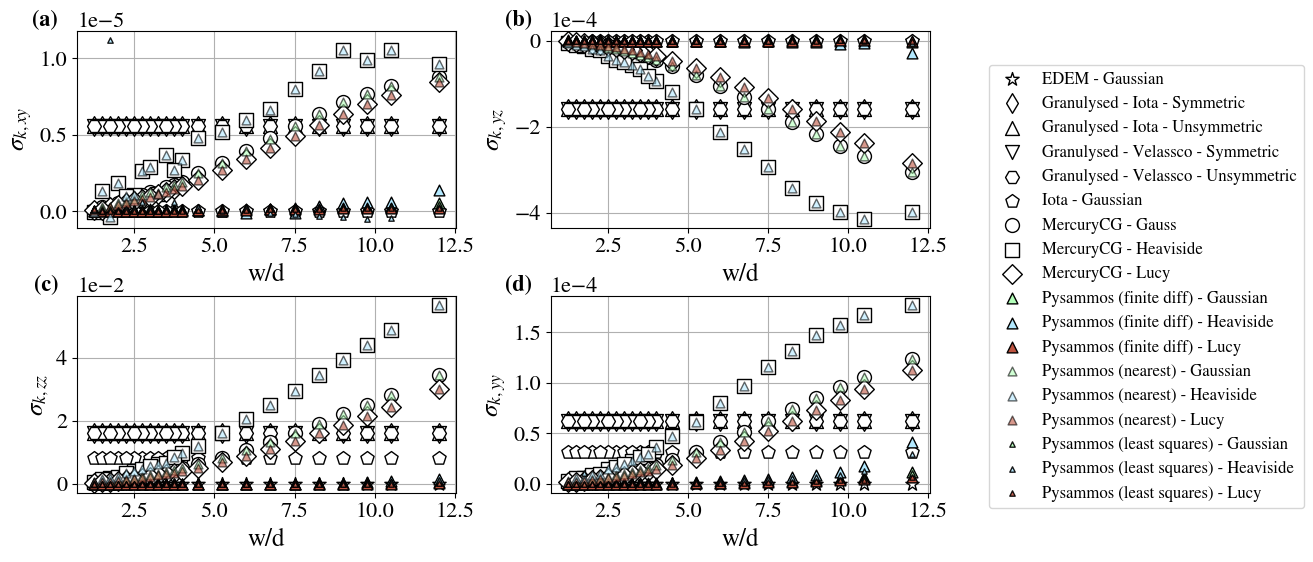

In [56]:
# FIGURE
fig, axs = plt.subplots(2, 2, figsize=(11,6))
# GENERAL INFO
markers = ['*', 'd', '^', 'v', 'H', 'p', 'o', 's', 'D']  # Different markers

# 1. xy kinetic stress
plot_JP_data(axs[0, 0], markers, 'Kinetic Stress XY')
axs[0, 0].set_ylabel(r'$\sigma_{k,xy}$')
plot_pysammos_data(axs[0, 0], 'kinetic_tensor', (0, 1))
plot_pysammos_no_interp_data(axs[0, 0], 'kinetic_tensor', (0,1))
plot_pysammos_least_squares_data(axs[0, 0], 'kinetic_tensor', (0,1))
#plot_pysammos_least_squares_newsign_data(axs[0, 0], 'kinetic_tensor', (0,1))

# 2. yz kinetic stress
plot_JP_data(axs[0, 1], markers, 'Kinetic Stress YZ')
axs[0, 1].set_ylabel(r'$\sigma_{k,yz}$')
plot_pysammos_data(axs[0, 1], 'kinetic_tensor', (1, 2))
plot_pysammos_no_interp_data(axs[0, 1], 'kinetic_tensor', (1,2))
plot_pysammos_least_squares_data(axs[0, 1], 'kinetic_tensor', (1,2))
#plot_pysammos_least_squares_newsign_data(axs[0, 1], 'kinetic_tensor', (1,2))

# 3. xx kinetic stress
plot_JP_data(axs[1, 0], markers, 'Kinetic Stress ZZ')
axs[1, 0].set_ylabel(r'$\sigma_{k,zz}$')
plot_pysammos_data(axs[1, 0], 'kinetic_tensor', (2, 2))
plot_pysammos_no_interp_data(axs[1, 0], 'kinetic_tensor', (2,2))
plot_pysammos_least_squares_data(axs[1, 0], 'kinetic_tensor', (2,2))
#plot_pysammos_least_squares_newsign_data(axs[1, 0], 'kinetic_tensor', (2,2))

# 4. yy kinetic stress
plot_JP_data(axs[1, 1], markers, 'Kinetic Stress YY')
axs[1, 1].set_ylabel(r'$\sigma_{k,yy}$')
plot_pysammos_data(axs[1, 1], 'kinetic_tensor', (1,1))
plot_pysammos_no_interp_data(axs[1, 1], 'kinetic_tensor', (1,1))
plot_pysammos_least_squares_data(axs[1, 1], 'kinetic_tensor', (1,1))
#plot_pysammos_least_squares_newsign_data(axs[1, 1], 'kinetic_tensor', (1,1))

# legend 
axs[0,1].legend(loc='center right', fontsize=12, bbox_to_anchor=(2.01, -0.3))

# Add grid, labels, and formatting
labels = ['(a)', '(b)', '(c)', '(d)']
axs_flat = axs.flatten()
for i, ax in enumerate(axs_flat):
    ax.grid()
    ax.set_xlabel('w/d')
    ax.ticklabel_format(axis='y', style='scientific', scilimits=(-1, 1))
    ax.text(-0.05, 1.0, labels[i], transform=ax.transAxes, fontsize=16,
        fontweight='bold', va='bottom', ha='right' )
# Layout adjustments
plt.subplots_adjust(hspace=0.35, wspace=0.25)
# Save figure
plt.savefig('/exports/csce/datastore/geos/users/s1857688/Paper_Writing/coarse_graining/benchmark_kinten.png',
    dpi=600,
    bbox_inches='tight',
    pad_inches=0)